In [15]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
%matplotlib inline


In [27]:
# Use your uploaded image (no upload needed)
filename = "image1.jpeg"

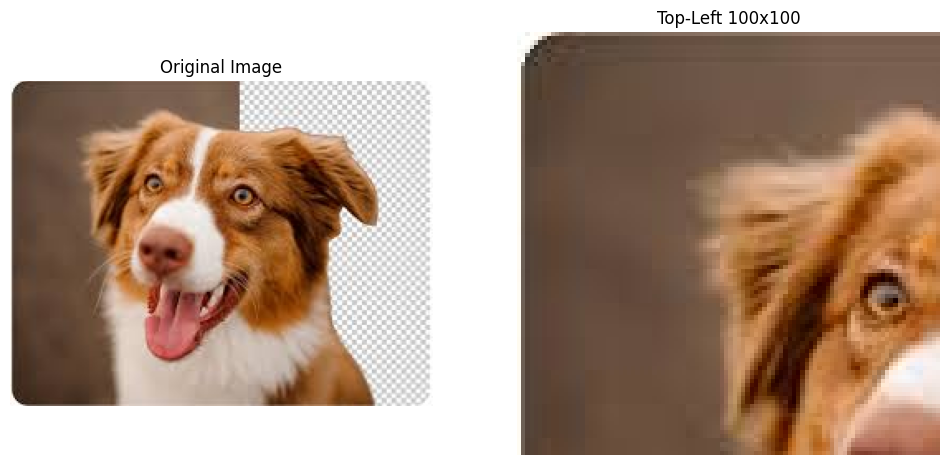

In [17]:
# Exercise 1 - Original + Top Left 100x100
img = np.array(Image.open(filename))
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img[:100,:100])
plt.title("Top-Left 100x100")
plt.axis('off')
plt.show()

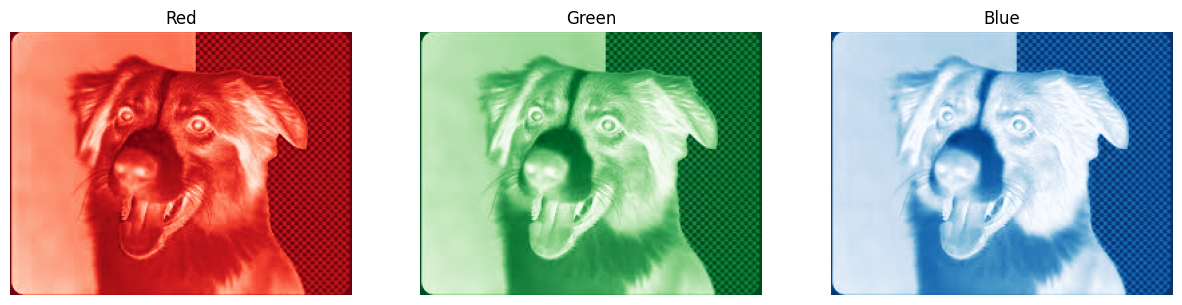

In [18]:
# Exercise 1 - RGB Channels
r,g,b = img[:,:,0], img[:,:,1], img[:,:,2]
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(r, cmap='Reds'); plt.title("Red"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(g, cmap='Greens'); plt.title("Green"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(b, cmap='Blues'); plt.title("Blue"); plt.axis('off')
plt.show()

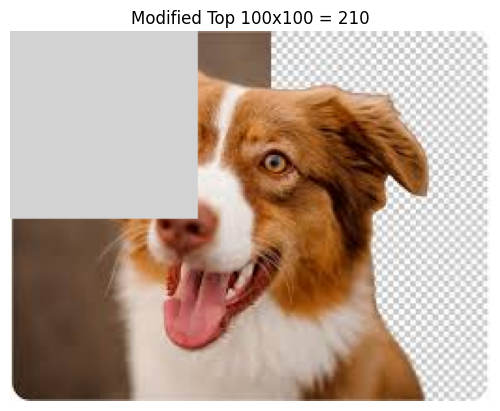

In [19]:
# Exercise 1 - Modify top 100x100 to 210
mod = img.copy()
mod[:100,:100] = 210
plt.imshow(mod)
plt.title("Modified Top 100x100 = 210")
plt.axis('off')
plt.show()

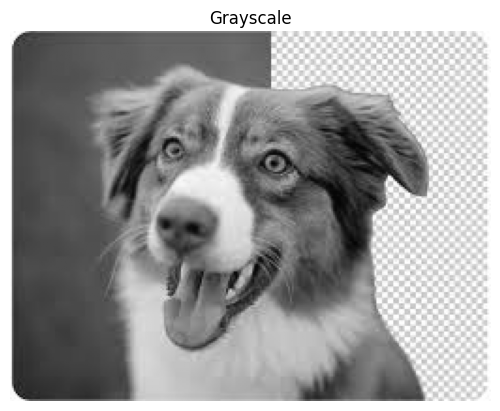

In [20]:
# Exercise 2 - Grayscale
gray = np.array(Image.open(filename).convert('L'))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

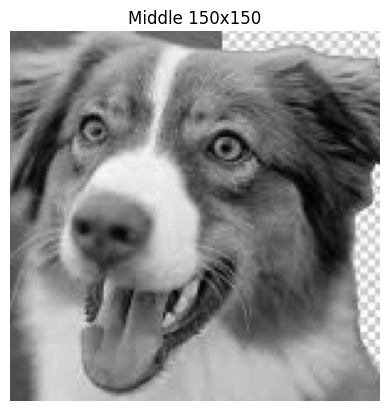

In [21]:
# Exercise 2 - Middle 150x150
h,w = gray.shape
middle = gray[h//2-75:h//2+75, w//2-75:w//2+75]
plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150")
plt.axis('off')
plt.show()

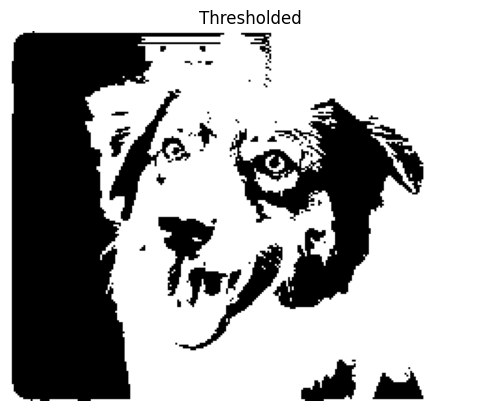

In [22]:
# Exercise 2 - Threshold
binary = np.where(gray < 100, 0, 255).astype(np.uint8)
plt.imshow(binary, cmap='gray')
plt.title("Thresholded")
plt.axis('off')
plt.show()

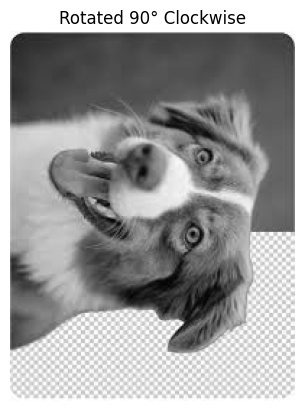

In [23]:
# Exercise 2 - Rotate 90° clockwise
rotated = np.rot90(gray, k=3)
plt.imshow(rotated, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis('off')
plt.show()

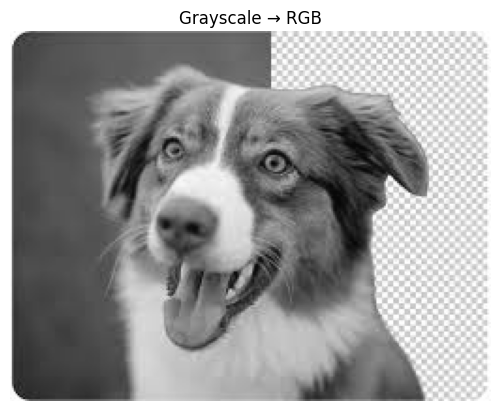

In [24]:
# Exercise 2 - Grayscale to RGB
rgb_gray = np.stack([gray]*3, axis=-1)
plt.imshow(rgb_gray)
plt.title("Grayscale → RGB")
plt.axis('off')
plt.show()

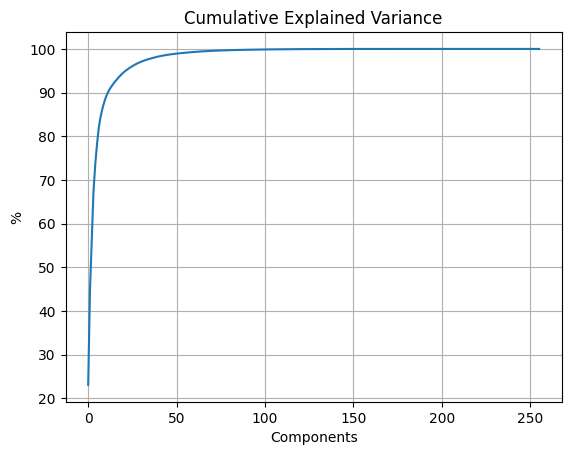

In [25]:
# PCA from scratch
X = gray.astype(float)
h, w = X.shape
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-8
X_std = (X - mean) / std

cov = np.cov(X_std, rowvar=False)
eigval, eigvec = np.linalg.eig(cov)
idx = eigval.argsort()[::-1]
eigval = eigval[idx].real
eigvec = eigvec[:, idx].real

cum_var = np.cumsum(eigval / eigval.sum())
plt.plot(cum_var*100)
plt.title("Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("%")
plt.grid()
plt.show()

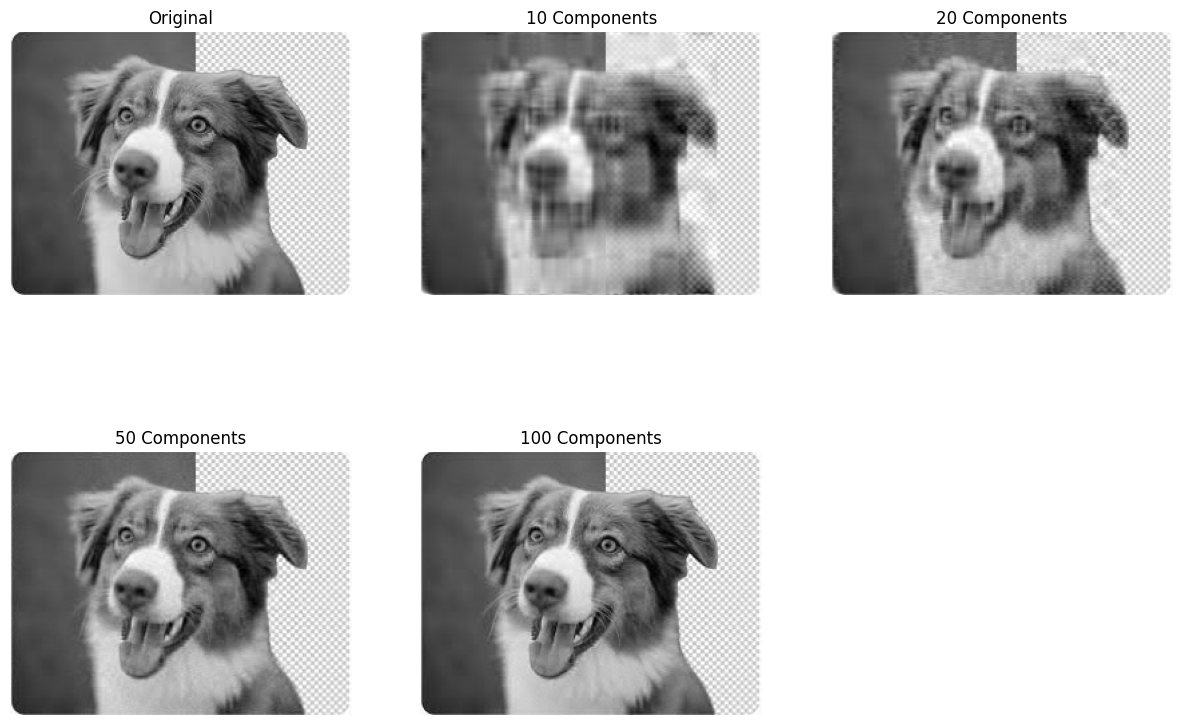

In [26]:
# Exercise 3 - Reconstruct with 4 different k (10,20,50,100)
def reconstruct(k):
    V = eigvec[:, :k]
    proj = X_std @ V
    rec = (proj @ V.T) * std + mean
    return np.clip(rec, 0, 255).astype(np.uint8)

plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

ks = [10,20,50,100]
for i,k in enumerate(ks,2):
    rec = reconstruct(k)
    plt.subplot(2,3,i)
    plt.imshow(rec, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis('off')
plt.show()